# immap2 first-iteration testbench — SENSE vs SoftSense

Mimics exactly one iteration of the `immap2` loop body (init -> mean shift -> denoise ->
prox/CG -> diffusion update) under two encoding operators: single-map `Sense` and
multi-map `SoftSense`. The goal is an apples-to-apples look at the data-consistency
(prox) step and the resulting update.

Design choices (faithful to `immap2`, adapted for the multi-component soft image):
- **Denoiser** acts on a single complex image. Soft SENSE has `M` components, so the
  prior is applied to **component 0 only** (the reconstruction); the extra components
  are constrained by data consistency in the CG prox. Change `denoise_primary` if your
  framework denoises components differently.
- The original passes `torch.squeeze(...)` into `cg`; that collapses the coil singleton
  and relies on broadcasting, which collides `M` with `C` for the soft shape. We keep
  canonical shapes for both paths — same math, no squeeze.
- `init_diff` is replicated inline as `sigma_max * randn_like(E.H(y))` so both operators
  get correctly-shaped, **seed-aligned** init (component 0 of the soft init == the SENSE
  init), making the comparison fair.

In [2]:
import os
os.chdir('/scratch/ee2178/ImMAP')

import torch

from operators import Mask, Sense, FFT2D, Identity
from operators.sense import SoftSense
from physics.mask import make_acc_mask
from physics.smaps import espirit_soft
from datasets.fastmri.common import load_knee_data
from training.common import load_model
from visualization.image import plot_image, save_image
from solvers import cg
from physics.nle import whiten_from_kspace

device = 'cuda'

## Helpers — denoiser wrappers + a single immap2 loop-body pass

In [3]:
def denoise_sense(denoiser, x_t, sigma_t):
    """x_t: (B, 1, Nx, Ny) complex."""
    x_hat, _ = denoiser(x_t, Identity(), sigma_t)
    return x_hat


def denoise_primary(denoiser, x_t, sigma_t):
    """x_t: (B, M, 1, Nx, Ny). Denoise component 0 and component 1 separately."""
    x_hat = x_t.clone()
    with torch.no_grad():
        prim, _ = denoiser(x_t[:, 0], Identity(), sigma_t)   # (B,1,Nx,Ny)
        sec, _ = denoiser(x_t[:, 1], Identity(), sigma_t)   # (B,1,Nx,Ny)
    x_hat[:, 0] = prim
    x_hat[:, 1] = sec
    return x_hat


def immap2_first_iter(
    y, sigma_y, denoise_fn, E,
    lam=2.0, sigma_max=1.0, beta=0.05, h_0=0.01, seed=0, iters=1,
    save_dir=None,
):
    for i in range(iters):
        with torch.no_grad():
            if i == 0:
                EHy = E.H(y)
                x_t = sigma_max * torch.randn_like(EHy)
                t = 1
                x_t = x_t + torch.mean(EHy)
                sigma_t = sigma_max
            else:
                x_t = x_t_next

            x_hat_t = denoise_fn(x_t, sigma_t)

            sigma_t_sq = torch.mean((x_hat_t - x_t).abs() ** 2)
            sigma_t = torch.sqrt(sigma_t_sq)
            p_t = lam * sigma_y ** 2 / (sigma_t_sq / (1 + sigma_t_sq))
            h_t = h_0 * t / (1 + h_0 * (t - 1))
            gamma_t = sigma_t * ((1 - beta * h_t) ** 2 - (1 - h_t) ** 2) ** 0.5

            def A(x, E=E, p_t=p_t):
                return E.H(E(x)) + p_t * x

            rhs = p_t * x_hat_t + EHy
            v_t, tol_reached = cg(A, rhs, max_iter=500, tol=1e-3, verbose=False)

            x_t_next = x_t + h_t * (v_t - x_t) + gamma_t * torch.randn_like(x_t)

            if t % 5 == 0 and save_dir:
                v_save = v_t[:, 0] if v_t.ndim == 5 else v_t   # soft: component 0
                fname = os.path.join(save_dir, f"vt_iter{t:03d}_sigma{sigma_t.item():.3f}.png")
                save_image(v_save, fname)

            t = t + 1
    return dict(
        x_t=x_t, x_hat_t=x_hat_t, v_t=v_t, x_t_next=x_t_next,
        sigma_t=sigma_t, p_t=p_t, h_t=h_t, gamma_t=gamma_t,
        tol_reached=tol_reached,
    )
    

## Load data, denoiser, and maps

Single-map path uses the ground-truth `smaps`; soft path estimates `M=2` maps with
`espirit_soft`. `sigma_y` is a placeholder — swap in your whitened `sigma_n`.

In [36]:
fname = 'file1000052.h5'
kspace, smaps, knee_mask, gnd_truth = load_knee_data(
    kspace_fname=fname, slice_idx=15, device=device
)
mask = make_acc_mask(shape=kspace[0, 0].shape, accel=6, acs_lines=20, device=device)
y = mask * kspace
B, C, Nx, Ny = kspace.shape

denoiser_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDS_Denoiser/config.json'
net = load_model(denoiser_path, device=device)

sigma_y = 1e-2  # TODO: replace with whitened sigma_n from whiten_from_kspace

# soft maps (M=2)
smaps_soft = espirit_soft(
    y/5e3, acs_size=(24, 24), kernel_size=8,
    thresh_rowspace=0.005, thresh_eig=0.995, num_maps=2,
)
smaps_soft = torch.flip(smaps_soft, dims=(-2, -1))  # same flip applied to espirit

Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1000052.h5
Power method returns L = (3387.782470703125+3.1581148505210876e-06j)


## Run the first iteration under each operator

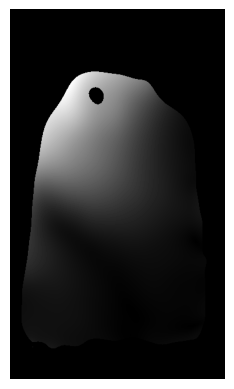

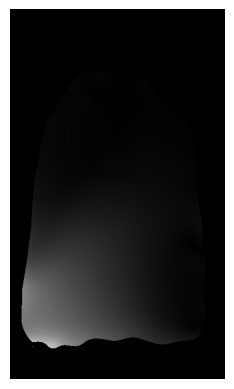

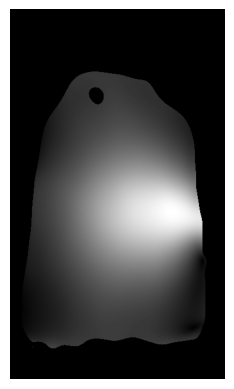

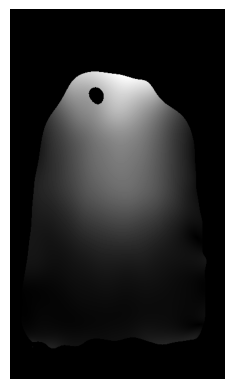

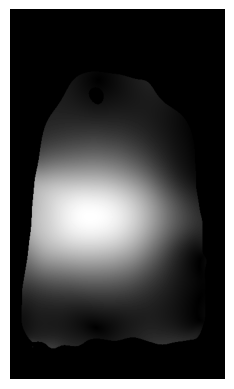

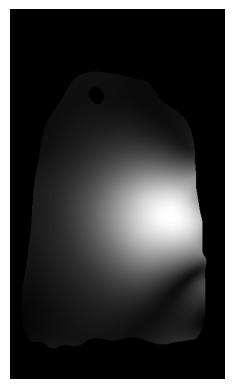

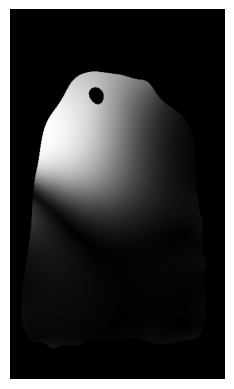

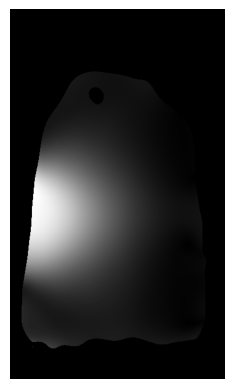

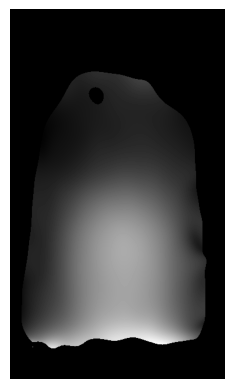

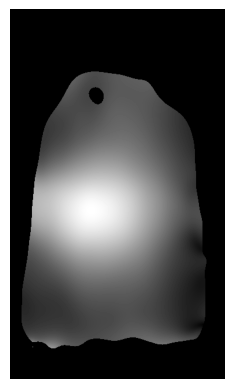

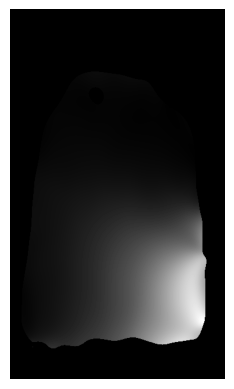

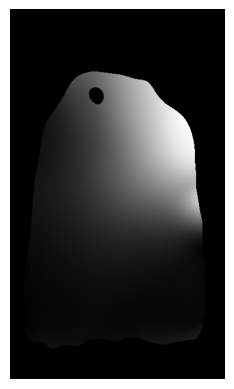

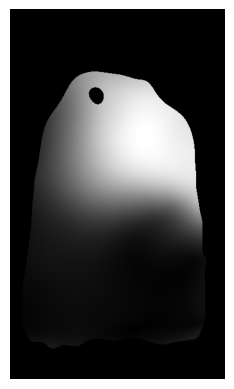

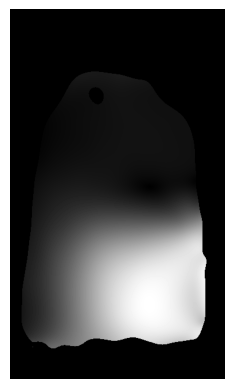

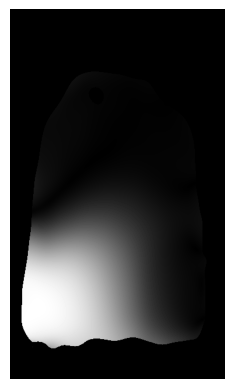

In [39]:
for i in range(smaps_soft.shape[2]):
    # plot_image(smaps_soft[0, 0, i])
    plot_image(smaps[0, i])
    # plot_image(smaps_soft[0, 1, i])
    # plot_image(smaps_soft[0, 2, i])

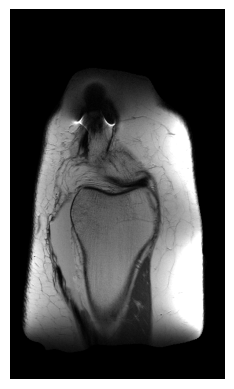

In [50]:
# Examine what the coil combined images actually look like:
CC = Sense(smaps_soft[:, 0]).H @ FFT2D().H

gt = CC(kspace)
plot_image(gt, contrast=True)


In [43]:
E_sense = Mask(mask) @ FFT2D() @ Sense(smaps)
E_soft  = Mask(mask) @ FFT2D() @ SoftSense(smaps_soft)

out_sense = immap2_first_iter(
    y, sigma_y, lambda x, s: denoise_sense(net, x, s), E_sense, seed=0, iters = 150,
)
out_soft = immap2_first_iter(
    y, sigma_y, lambda x, s: denoise_primary(net, x, s), E_soft, seed=0, iters = 150
)

for name, o in [("SENSE", out_sense), ("SoftSense", out_soft)]:
    print(f"[{name:9s}] sigma_t={o['sigma_t'].item():.4f}  "
          f"p_t={o['p_t'].item():.3e}  h_t={o['h_t']:.4f}  "
          f"gamma_t={o['gamma_t'].item():.4f}  tol_reached={o['tol_reached']}")

[SENSE    ] sigma_t=0.1695  p_t=7.159e-03  h_t=0.6024  gamma_t=0.1500  tol_reached=True
[SoftSense] sigma_t=0.0583  p_t=5.906e-02  h_t=0.6024  gamma_t=0.0516  tol_reached=True


## Compare the prox output and the update

`v_t` is the data-consistency (CG prox) result — the quantity that differs most between
the two operators. For soft SENSE we show component 0 (the reconstruction) and component
1 (the nuisance/error component).

x_hat_t  — SENSE


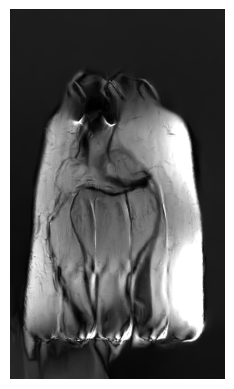

x_hat_t  — SoftSense (component 0)


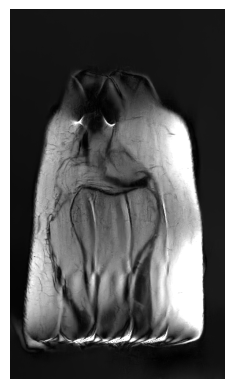

In [44]:
# Denoised init x_hat_t
print("x_hat_t  — SENSE")
plot_image(out_sense["x_hat_t"], contrast=True)
print("x_hat_t  — SoftSense (component 0)")
plot_image(out_soft["x_hat_t"][:, 0], contrast=True)

v_t  — SENSE


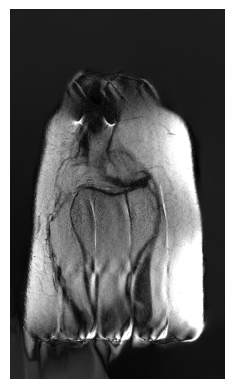

v_t  — SoftSense (component 0)


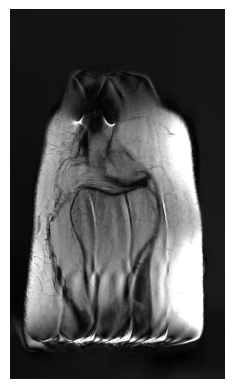

v_t  — SoftSense (component 1, nuisance)


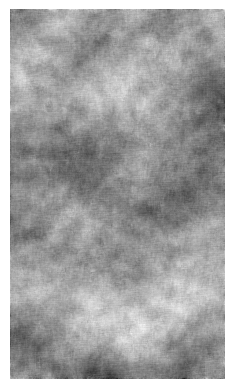

In [45]:
# Prox / CG output v_t
print("v_t  — SENSE")
plot_image(out_sense["v_t"], contrast=True)
print("v_t  — SoftSense (component 0)")
plot_image(out_soft["v_t"][:, 0], contrast=True)
print("v_t  — SoftSense (component 1, nuisance)")
plot_image(out_soft["v_t"][:, 1], contrast=True)

x_t_next  — SENSE


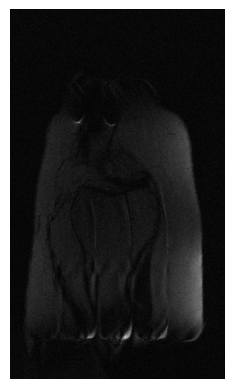

x_t_next  — SoftSense (component 0)


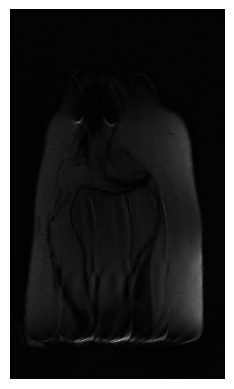

||v_t(soft, comp0) - v_t(sense)|| / ||v_t(sense)|| = 3.462e-01


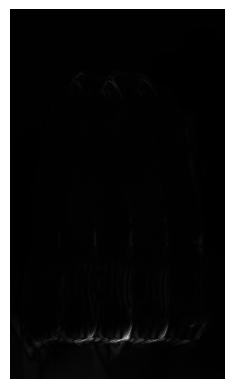

In [51]:
# Post-update x_t (after the diffusion step)
print("x_t_next  — SENSE")
plot_image(out_sense["x_t_next"])
print("x_t_next  — SoftSense (component 0)")
plot_image(out_soft["x_t_next"][:, 0])

# difference between the two prox reconstructions (component 0)
diff = (out_soft["v_t"][:, 0] - out_sense["v_t"]).abs()
print(f"||v_t(soft, comp0) - v_t(sense)|| / ||v_t(sense)|| = "
      f"{diff.norm().item() / (out_sense['v_t'].abs().norm().item() + 1e-12):.3e}")
plot_image(diff)